In [8]:
print("Welcome To  Our Project")

Welcome To  Our Project


In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import joblib
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
import xgboost as xgb

In [11]:
# Load your clean dataset
df = pd.read_csv("final_davangere_kvk_1000_rows.csv")

df.head()


,N,P,K,pH,recommended_N_kg_per_acre,recommended_P2O5_kg_per_acre,recommended_K2O_kg_per_acre,urea,ssp,mop
0,95.0,7.0,103.0,8.02,51.24,28.56,24.59,111.40,178.53,40.99
1,58.0,5.0,320.0,8.15,57.57,29.06,15.00,125.15,181.64,25.00
2,64.0,9.0,191.0,8.04,57.80,27.45,19.76,125.65,171.57,32.93
3,98.0,10.0,138.0,6.45,51.15,27.63,22.85,111.20,172.69,38.08
4,92.0,7.0,110.0,8.04,50.04,28.60,23.70,108.78,178.76,39.50


In [12]:
print(df.info())
# print(df.describe())
pd.set_option("display.max_columns", None)
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   N                             1000 non-null   float64
 1   P                             1000 non-null   float64
 2   K                             1000 non-null   float64
 3   pH                            989 non-null    float64
 4   recommended_N_kg_per_acre     1000 non-null   float64
 5   recommended_P2O5_kg_per_acre  1000 non-null   float64
 6   recommended_K2O_kg_per_acre   1000 non-null   float64
 7   urea                          1000 non-null   float64
 8   ssp                           1000 non-null   float64
 9   mop                           1000 non-null   float64
dtypes: float64(10)
memory usage: 78.3 KB
None


,N,P,K,pH,recommended_N_kg_per_acre,recommended_P2O5_kg_per_acre,recommended_K2O_kg_per_acre,urea,ssp,mop
count,1000.000000,1000.000000,1000.000000,989.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,88.573000,14.854000,144.890000,7.281264,52.262200,25.216680,22.333610,113.613640,157.604210,37.222740
std,20.672107,8.767871,48.275734,2.034299,4.198507,3.097844,2.898183,9.127266,19.360956,4.830542
min,51.000000,5.000000,17.000000,1.550000,43.110000,15.000000,15.000000,93.710000,93.750000,25.000000
25%,69.750000,9.000000,117.000000,6.780000,49.037500,23.450000,20.250000,106.612500,146.580000,33.750000
50%,91.000000,13.000000,158.000000,7.450000,51.865000,25.985000,21.615000,112.745000,162.390000,36.030000
75%,104.000000,18.000000,180.000000,7.810000,55.932500,27.602500,23.942500,121.595000,172.532500,39.905000
max,129.000000,79.000000,320.000000,47.490000,61.520000,30.290000,31.350000,133.750000,189.280000,52.250000


In [13]:
df.isna().sum()


N                                0
P                                0
K                                0
pH                              11
recommended_N_kg_per_acre        0
recommended_P2O5_kg_per_acre     0
recommended_K2O_kg_per_acre      0
urea                             0
ssp                              0
mop                              0
dtype: int64

In [14]:
df = df[df["pH"] <= 8]   # remove impossible pH values >9
df = df[df["pH"] >= 5]   # remove impossible pH <3


In [15]:
# Fix missing soil pH values
median_pH = df["pH"].median()
df["pH"].fillna(median_pH, inplace=True)

df.isna().sum()


C:\Users\keert\AppData\Local\Temp\ipykernel_7240\842919231.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["pH"].fillna(median_pH, inplace=True)


N                               0
P                               0
K                               0
pH                              0
recommended_N_kg_per_acre       0
recommended_P2O5_kg_per_acre    0
recommended_K2O_kg_per_acre     0
urea                            0
ssp                             0
mop                             0
dtype: int64

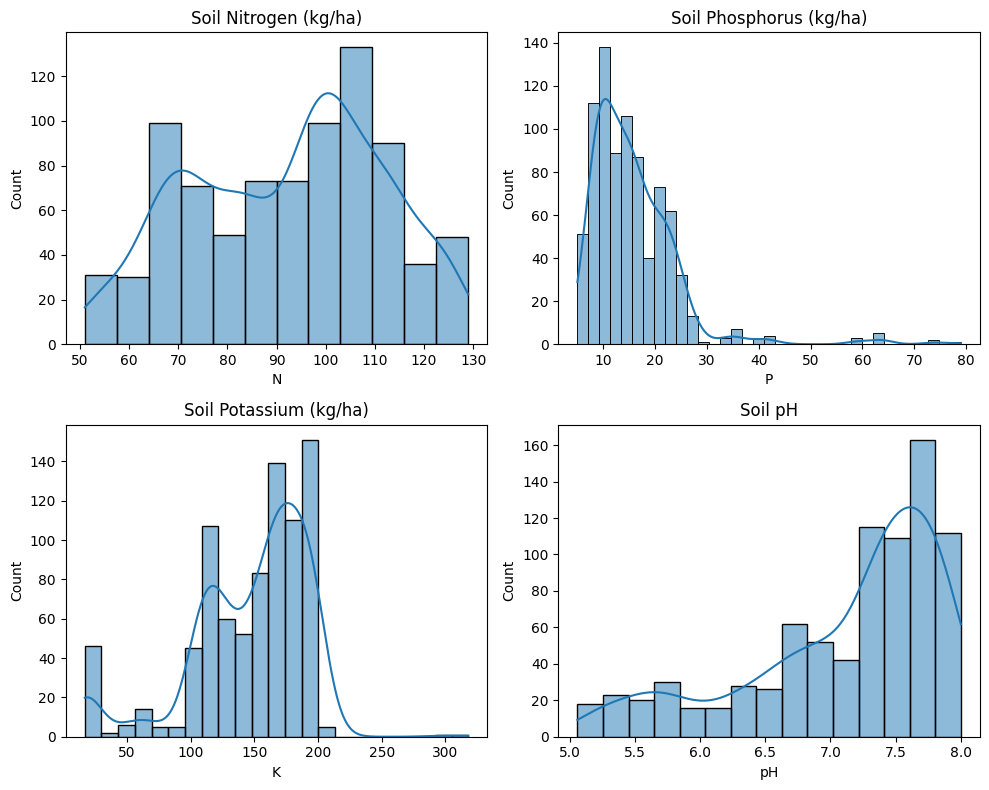

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(df["N"], kde=True, ax=axes[0,0])
axes[0,0].set_title("Soil Nitrogen (kg/ha)")

sns.histplot(df["P"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Soil Phosphorus (kg/ha)")

sns.histplot(df["K"], kde=True, ax=axes[1,0])
axes[1,0].set_title("Soil Potassium (kg/ha)")

sns.histplot(df["pH"], kde=True, ax=axes[1,1])
axes[1,1].set_title("Soil pH")

plt.tight_layout()
plt.show()


In [17]:
print("pH range after filtering:", df['pH'].min(), df['pH'].max())
print(df['pH'].describe())


pH range after filtering: 5.06 8.0
count    832.000000
mean       7.109387
std        0.751890
min        5.060000
25%        6.717500
50%        7.380000
75%        7.680000
max        8.000000
Name: pH, dtype: float64


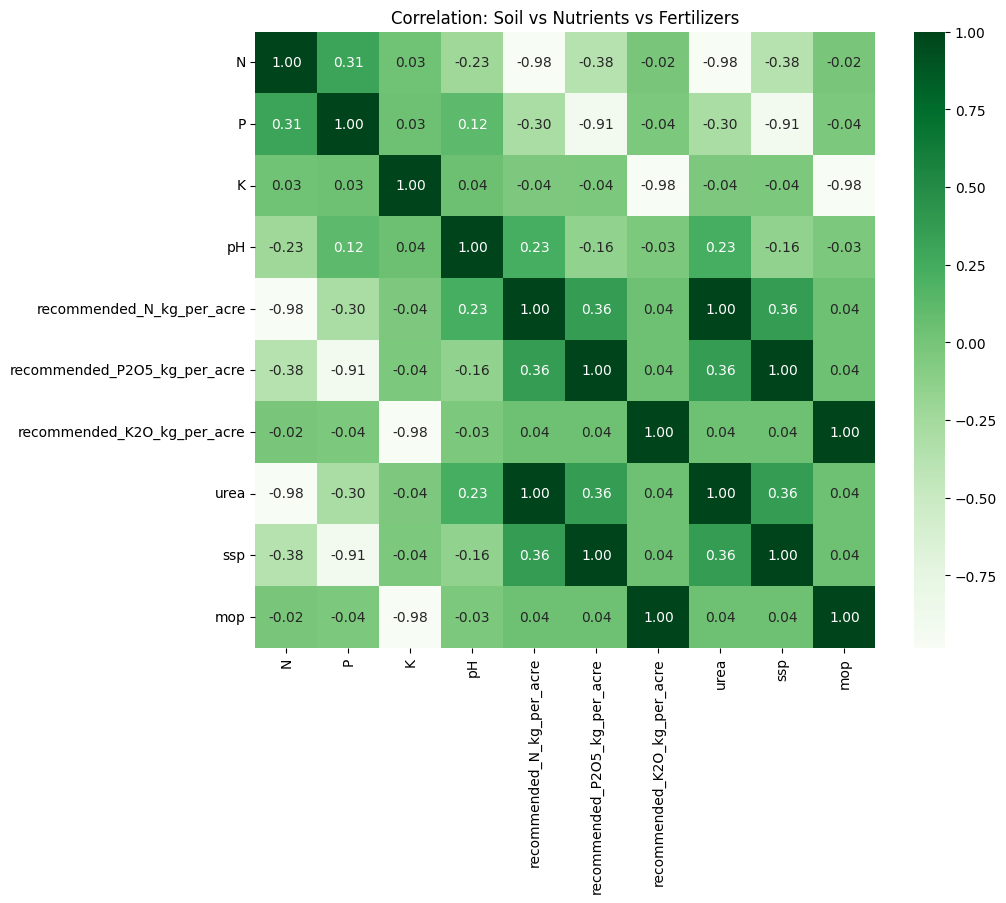

In [18]:
plt.figure(figsize=(10, 8))

corr_cols = [
    "N",
    "P",
    "K",
    "pH",
    "recommended_N_kg_per_acre",
    "recommended_P2O5_kg_per_acre",
    "recommended_K2O_kg_per_acre",
    "urea",
    "ssp",
    "mop"
]

sns.heatmap(df[corr_cols].corr(),cmap="Greens", annot=True, fmt=".2f")
plt.title("Correlation: Soil vs Nutrients vs Fertilizers")
plt.show()


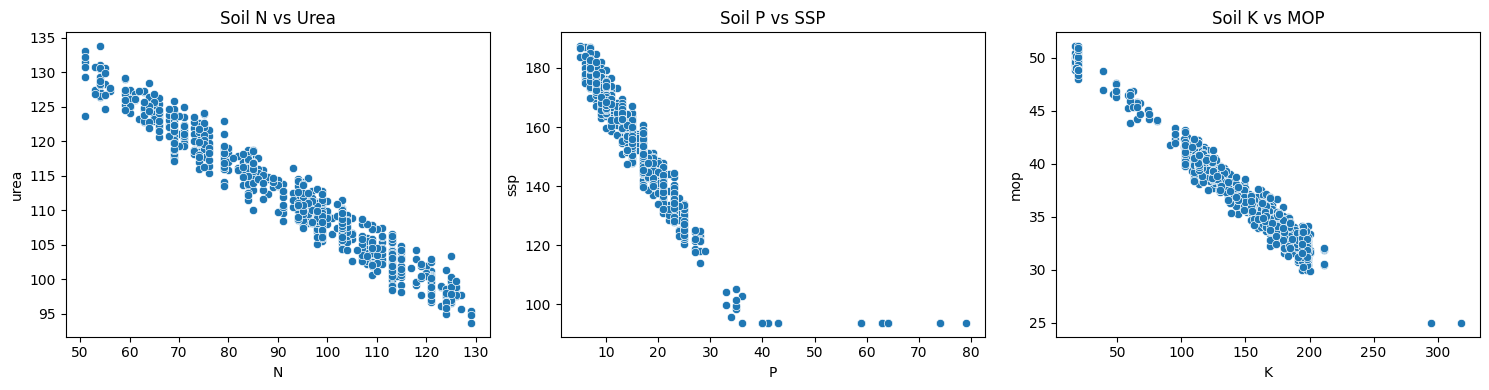

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x="N", y="urea", data=df, ax=axes[0])
axes[0].set_title("Soil N vs Urea")

sns.scatterplot(x="P", y="ssp", data=df, ax=axes[1])
axes[1].set_title("Soil P vs SSP")

sns.scatterplot(x="K", y="mop", data=df, ax=axes[2])
axes[2].set_title("Soil K vs MOP")

plt.tight_layout()
plt.show()


In [20]:
X = df[["N", "P", "K", "pH"]]
y = df[["urea", "ssp", "mop"]]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((665, 4), (167, 4), (665, 3), (167, 3))

In [23]:
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5   # fixed for older sklearn
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 {name} PERFORMANCE")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²    : {r2:.4f}")
    
    return mae, rmse, r2


In [63]:
rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=350, #more tres higher accuracy
        max_depth=8, # Tree depth -prevents overfitting
        random_state=42, #repeats same results
        n_jobs=-1 #use all CPU cores --faster training
    )
)

rf_model.fit(X_train, y_train) # learn relationship between soil nutients and fertlizer amounts
rf_pred = rf_model.predict(X_test)# predict for unseen data

rf_results = evaluate_model(y_test, rf_pred, "Random Forest")



📊 Random Forest PERFORMANCE
MAE  : 1.781
RMSE : 2.616
R²    : 0.9598


In [25]:
xgb_model = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=350,
        max_depth=8,
        learning_rate=0.07,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_results = evaluate_model(y_test, xgb_pred, "XGBoost")



📊 XGBoost PERFORMANCE
MAE  : 2.163
RMSE : 3.162
R²    : 0.9450


In [26]:
print("\n===================")
print("MODEL COMPARISON")
print("===================")
print(f"Random Forest R² : {rf_results[2]:.4f}")
print(f"XGBoost R²       : {xgb_results[2]:.4f}")




MODEL COMPARISON
Random Forest R² : 0.9568
XGBoost R²       : 0.9450


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np


In [28]:
def multioutput_rmse(y_true, y_pred):
    """
    Compute RMSE for each output (Urea, SSP, MOP),
    then return the average RMSE.
    Lower is better.
    """
    mse_each = mean_squared_error(y_true, y_pred, multioutput="raw_values")
    rmse_each = np.sqrt(mse_each)
    return rmse_each.mean()

# We want to MINIMIZE RMSE, so greater_is_better=False
rmse_scorer = make_scorer(multioutput_rmse, greater_is_better=False)


In [29]:
# Hyperparameter grid for Random Forest
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
}

base_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=5,
    scoring=rmse_scorer,   # uses average RMSE across Urea+SSP+MOP
    n_jobs=-1,
    verbose=1,
)

print("🔄 Running advanced hyperparameter tuning (this may take a bit)...")
grid_search.fit(X_train, y_train)   # y_train has 3 columns

print("\n✅ Best hyperparameters for Random Forest (multi-output, avg RMSE):")
print(grid_search.best_params_)
print("Best CV (negative avg RMSE):", grid_search.best_score_)


🔄 Running advanced hyperparameter tuning (this may take a bit)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best hyperparameters for Random Forest (multi-output, avg RMSE):
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV (negative avg RMSE): -2.705265137737207


In [30]:
best_params = grid_search.best_params_

rf_best = RandomForestRegressor(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42,
    n_jobs=-1,
)

from sklearn.multioutput import MultiOutputRegressor

rf_tuned = MultiOutputRegressor(rf_best)

rf_tuned.fit(X_train, y_train)

print("✅ Tuned Random Forest (multi-output) fitted on Urea, SSP, MOP.")


✅ Tuned Random Forest (multi-output) fitted on Urea, SSP, MOP.


In [31]:
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_results = evaluate_model(y_test, rf_tuned_pred, "Random Forest (Tuned, avg RMSE)")



📊 Random Forest (Tuned, avg RMSE) PERFORMANCE
MAE  : 1.830
RMSE : 2.667
R²    : 0.9578


MAE 1.830

Errors reduced from 1.855 → 1.830

Improvement: 1.3% better

RMSE 2.667

Errors reduced from 2.696 → 2.667

Improvement: 1.07% better

R² 0.9578

Improved from 0.9568 → 0.9578

Slightly better modelling of variance

In [32]:
# ==================================================
# HYPERPARAMETER TUNING — XGBOOST
# ==================================================
import xgboost as xgb

xgb_param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.07, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

print("🔄 Running XGBoost hyperparameter tuning...")
xgb_grid.fit(X_train, y_train["urea"])

print("\nBest XGB parameters:", xgb_grid.best_params_)


🔄 Running XGBoost hyperparameter tuning...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best XGB parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [33]:
xgb_best = MultiOutputRegressor(
    xgb.XGBRegressor(
        **xgb_grid.best_params_,
        objective="reg:squarederror",
        random_state=42
    )
)

xgb_best.fit(X_train, y_train)
xgb_best_pred = xgb_best.predict(X_test)


In [34]:

xgb_best_results = evaluate_model(y_test, xgb_best_pred, "XGBoost (Tuned)")



📊 XGBoost (Tuned) PERFORMANCE
MAE  : 1.851
RMSE : 2.781
R²    : 0.9580


In [35]:
print("\n=========== FINAL MODEL COMPARISON (R² Scores) ===========")
print(f"Random Forest (Default)     : {rf_results[2]:.4f}")
print(f"Random Forest (Tuned)       : {rf_tuned_results[2]:.4f}")
print(f"XGBoost (Default)           : {xgb_results[2]:.4f}")
print(f"XGBoost (Tuned)             : {xgb_best_results[2]:.4f}")
print("==========================================================")



=========== FINAL MODEL COMPARISON (R² Scores) ===========
Random Forest (Default)     : 0.9568
Random Forest (Tuned)       : 0.9578
XGBoost (Default)           : 0.9450
XGBoost (Tuned)             : 0.9580


In [36]:
final_model = rf_tuned


In [37]:
final_pred = final_model.predict(X_test)
final_results = evaluate_model(y_test, final_pred, "Final Random Forest (Tuned)")

print("\n==============")
print("FINAL METRICS")
print("==============")
print(f"MAE  : {final_results[0]:.4f}")
print(f"RMSE : {final_results[1]:.4f}")
print(f"R²   : {final_results[2]:.4f}")



📊 Final Random Forest (Tuned) PERFORMANCE
MAE  : 1.830
RMSE : 2.667
R²    : 0.9578

FINAL METRICS
MAE  : 1.8302
RMSE : 2.6673
R²   : 0.9578


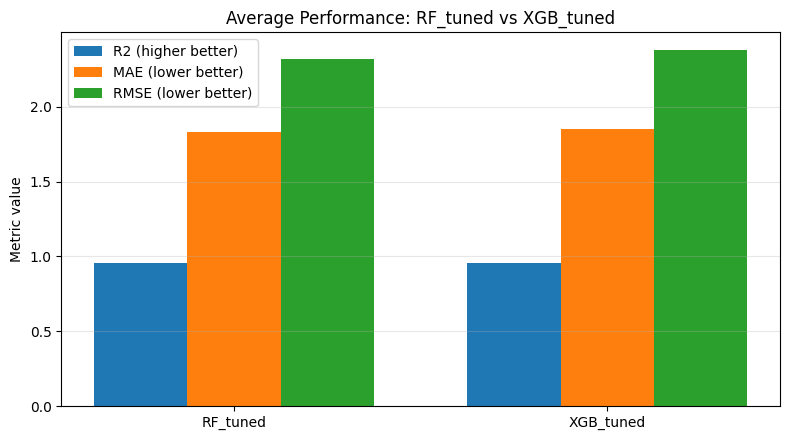

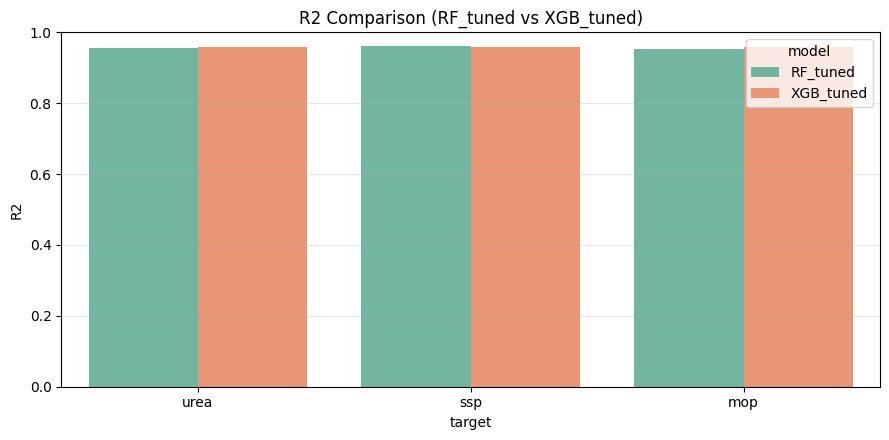

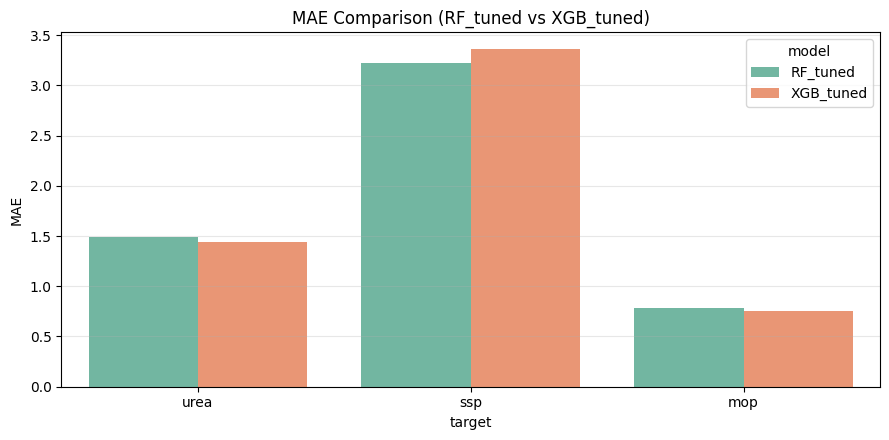

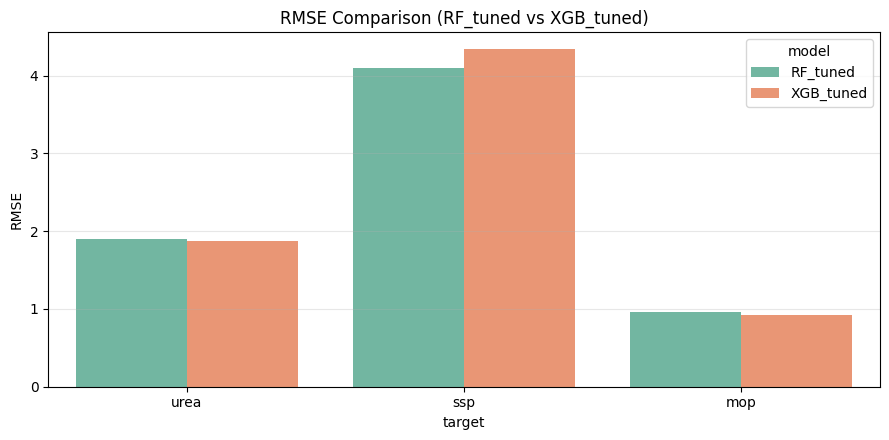

=== Aggregate (mean across targets) ===


,R2_mean,MAE_mean,RMSE_mean
RF_tuned,0.957778,1.830198,2.320014
XGB_tuned,0.958035,1.851371,2.377617



=== Per-target metrics ===


MAE                  R2                RMSE          
model   RF_tuned XGB_tuned  RF_tuned XGB_tuned  RF_tuned XGB_tuned
target                                                            
mop     0.780970  0.749565  0.954147  0.958470  0.963552  0.917005
ssp     3.219901  3.359682  0.962827  0.958363  4.101836  4.341125
urea    1.489723  1.444868  0.956359  0.957273  1.894653  1.874721

In [38]:
# ---------------------------
# Model comparison plots (Only RF_tuned vs XGB_tuned)
# ---------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Use ONLY tuned models
models_preds = {
    "RF_tuned": rf_tuned_pred,
    "XGB_tuned": xgb_best_pred
}

targets = y_test.columns.tolist()  # ['urea','ssp','mop']

# Compute metrics per model and per target
metrics = {}
for name, preds in models_preds.items():
    per_target = {}
    for i, col in enumerate(targets):
        y_true = y_test[col].values
        y_p = preds[:, i]
        mae = mean_absolute_error(y_true, y_p)
        rmse = np.sqrt(mean_squared_error(y_true, y_p))
        r2 = r2_score(y_true, y_p)
        per_target[col] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    # Aggregate (mean across targets)
    agg = {
        "MAE_mean": np.mean([per_target[t]["MAE"] for t in targets]),
        "RMSE_mean": np.mean([per_target[t]["RMSE"] for t in targets]),
        "R2_mean": np.mean([per_target[t]["R2"] for t in targets])
    }
    metrics[name] = {"per_target": per_target, "agg": agg}

# Convert to DataFrames
agg_df = pd.DataFrame({
    name: [metrics[name]["agg"]["R2_mean"],
           metrics[name]["agg"]["MAE_mean"],
           metrics[name]["agg"]["RMSE_mean"]]
    for name in metrics
}, index=["R2_mean", "MAE_mean", "RMSE_mean"]).T

# Per-target long form
rows = []
for name in metrics:
    for t in targets:
        row = {
            "model": name,
            "target": t,
            "R2": metrics[name]["per_target"][t]["R2"],
            "MAE": metrics[name]["per_target"][t]["MAE"],
            "RMSE": metrics[name]["per_target"][t]["RMSE"]
        }
        rows.append(row)
per_target_df = pd.DataFrame(rows)

# ---------------------------
# Plot 1: Average metrics
# ---------------------------
plt.figure(figsize=(8,4.5))
x = np.arange(len(agg_df.index))
width = 0.25

models = agg_df.index.tolist()
r2_vals = agg_df["R2_mean"].values
mae_vals = agg_df["MAE_mean"].values
rmse_vals = agg_df["RMSE_mean"].values

plt.bar(x - width, r2_vals, width, label='R2 (higher better)')
plt.bar(x, mae_vals, width, label='MAE (lower better)')
plt.bar(x + width, rmse_vals, width, label='RMSE (lower better)')

plt.xticks(x, models)
plt.ylabel("Metric value")
plt.title("Average Performance: RF_tuned vs XGB_tuned")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------
# Plot 2: Per-target grouped bars
# ---------------------------
for metric_name in ["R2", "MAE", "RMSE"]:
    plt.figure(figsize=(9,4.5))
    sns.barplot(data=per_target_df, x="target", y=metric_name,
                hue="model", palette="Set2")
    plt.title(f"{metric_name} Comparison (RF_tuned vs XGB_tuned)")
    if metric_name == "R2":
        plt.ylim(0,1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------
# View tables
# ---------------------------
print("=== Aggregate (mean across targets) ===")
display(agg_df)

print("\n=== Per-target metrics ===")
display(per_target_df.pivot_table(
    index="target", columns="model", values=["R2","MAE","RMSE"]
))


In [39]:
# -------------------------
# 5-FOLD CROSS VALIDATION
# -------------------------
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor  # <-- REQUIRED IMPORT
import numpy as np

# 1. Custom RMSE scorer (same as used in GridSearch)
def multioutput_rmse(y_true, y_pred):
    mse_each = mean_squared_error(y_true, y_pred, multioutput="raw_values")
    rmse_each = np.sqrt(mse_each)
    return rmse_each.mean()

rmse_scorer = make_scorer(multioutput_rmse, greater_is_better=False)

# 2. Build model with tuned hyperparameters
rf_cv = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )
)

# 3. Define 5-fold CV
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run CV on full dataset
cv_scores = cross_val_score(
    rf_cv,
    X,      # features
    y,      # labels
    scoring=rmse_scorer,
    cv=kfold,
    n_jobs=-1
)

# 5. Print results
print("\n📊 5-Fold Cross Validation Results (avg RMSE over Urea/SSP/MOP):")
print("Fold RMSEs:", -cv_scores)
print("Mean RMSE :", -cv_scores.mean())
print("Std Dev   :", cv_scores.std())



📊 5-Fold Cross Validation Results (avg RMSE over Urea/SSP/MOP):
Fold RMSEs: [2.32011739 2.4363988  2.45218307 2.36517265 2.44909495]
Mean RMSE : 2.4045933718780863
Std Dev   : 0.052814657982815476


   fold      rmse
0     1  2.320117
1     2  2.436399
2     3  2.452183
3     4  2.365173
4     5  2.449095
Mean RMSE:  2.4045933718780863
Std RMSE:   0.052814657982815476


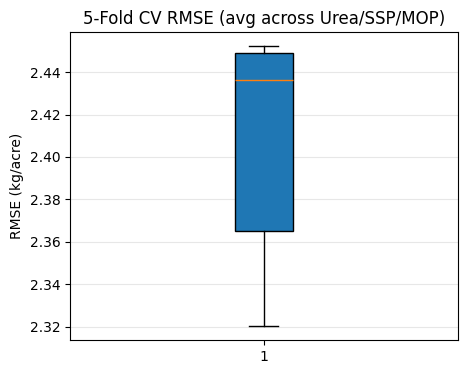

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# assume cv_scores is the array you printed (negative because scorer minimized)
# If cv_scores were negative from cross_val_score, convert:
fold_rmse = -cv_scores if cv_scores.mean() < 0 else cv_scores

# Create DataFrame for reporting
df_cv = pd.DataFrame({
    "fold": np.arange(1, len(fold_rmse) + 1),
    "rmse": fold_rmse
})
print(df_cv)
print("Mean RMSE: ", fold_rmse.mean())
print("Std RMSE:  ", fold_rmse.std())

# Boxplot
plt.figure(figsize=(5,4))
plt.boxplot(fold_rmse, vert=True, patch_artist=True)
plt.ylabel("RMSE (kg/acre)")
plt.title("5-Fold CV RMSE (avg across Urea/SSP/MOP)")
plt.grid(axis='y', alpha=0.3)
plt.show()


In [41]:
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, test_pred))
#Only a small performance drop (~2.1%) from train → test
# overfitinng happens when Train R² is very high
#Test R² is much lower


Train R²: 0.9793419394636717
Test R² : 0.9577776521871777


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_mae = mean_absolute_error(y_train, train_pred)
test_mae  = mean_absolute_error(y_test, test_pred)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)


Train MAE: 1.2253886454384595
Test MAE: 1.8301978535125139


In [43]:
print("CV Mean RMSE:", -cv_scores.mean())
print("CV Std Dev:", cv_scores.std())


CV Mean RMSE: 2.4045933718780863
CV Std Dev: 0.052814657982815476


In [44]:
test_row = df.iloc[828]
print(test_row)


N                               121.00
P                                35.00
K                               194.00
pH                                7.58
recommended_N_kg_per_acre        46.08
recommended_P2O5_kg_per_acre     16.24
recommended_K2O_kg_per_acre      18.98
urea                            100.18
ssp                             101.47
mop                              31.63
Name: 995, dtype: float64


In [45]:
X_single = test_row[["N", "P", "K", "pH"]].to_frame().T
pred = final_model.predict(X_single)[0]

print("Predicted Urea:", pred[0])
print("Predicted SSP:", pred[1])
print("Predicted MOP:", pred[2])


Predicted Urea: 101.32802647350587
Predicted SSP: 99.6338817857145
Predicted MOP: 32.66772083186077


In [46]:
print("Actual Urea:", test_row["urea"])
print("Actual SSP:", test_row["ssp"])
print("Actual MOP:", test_row["mop"])


Actual Urea: 100.18
Actual SSP: 101.47
Actual MOP: 31.63


In [47]:
abs_error = abs(test_row["urea"] - pred[0])
print("Absolute Error (Urea):", abs_error)

abs_error = abs(test_row["ssp"] - pred[1])
print("Absolute Error (SSP):", abs_error)

abs_error = abs(test_row["mop"] - pred[2])
print("Absolute Error (MOP):", abs_error)


Absolute Error (Urea): 1.1480264735058654
Absolute Error (SSP): 1.8361182142855057
Absolute Error (MOP): 1.0377208318607707


In [48]:
# 1. Pick one sample from the TEST SET
index = X_test.index[0]      # or choose any index
X_single = X_test.loc[index].to_frame().T

# 2. Predict using the model
pred = final_model.predict(X_single)[0]

# 3. Get ACTUAL fertilizers from y_test using the SAME INDEX
actual = y_test.loc[index]

print("Predicted Urea:", pred[0])
print("Predicted SSP:", pred[1])
print("Predicted MOP:", pred[2])

print("\nActual Urea:", actual["urea"])
print("Actual SSP:", actual["ssp"])
print("Actual MOP:", actual["mop"])

# 4. Error calculation
print("\nAbsolute Error (Urea):", abs(actual["urea"] - pred[0]))
print("Absolute Error (SSP):", abs(actual["ssp"] - pred[1]))
print("Absolute Error (MOP):", abs(actual["mop"] - pred[2]))


Predicted Urea: 107.79739682675013
Predicted SSP: 137.2163662673977
Predicted MOP: 34.721470328787696

Actual Urea: 108.31
Actual SSP: 134.24
Actual MOP: 33.38

Absolute Error (Urea): 0.5126031732498717
Absolute Error (SSP): 2.9763662673976796
Absolute Error (MOP): 1.3414703287876932


In [49]:
print("TRAIN ROWS:", sorted(X_train.index))
print("TEST ROWS :", sorted(X_test.index))


TRAIN ROWS: [3, 5, 7, 8, 10, 12, 13, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 31, 33, 34, 36, 38, 42, 44, 45, 46, 47, 48, 50, 51, 52, 54, 55, 56, 57, 58, 59, 62, 63, 64, 66, 70, 73, 74, 75, 76, 78, 79, 80, 85, 90, 91, 92, 93, 97, 98, 99, 103, 104, 106, 107, 111, 113, 114, 116, 117, 118, 120, 121, 122, 123, 128, 130, 131, 133, 134, 136, 137, 138, 139, 140, 145, 146, 147, 148, 149, 150, 151, 153, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 173, 175, 176, 177, 178, 179, 180, 182, 183, 184, 185, 187, 188, 189, 190, 191, 193, 194, 195, 197, 198, 199, 200, 201, 202, 203, 205, 206, 208, 209, 210, 211, 212, 214, 217, 218, 219, 221, 222, 223, 224, 225, 226, 227, 228, 229, 231, 232, 233, 234, 236, 237, 238, 239, 240, 241, 244, 245, 246, 248, 250, 251, 252, 254, 259, 260, 262, 263, 265, 266, 267, 268, 269, 270, 271, 272, 273, 275, 276, 277, 279, 280, 281, 282, 284, 285, 286, 288, 289, 290, 291, 293, 294, 297, 298, 300, 301, 302, 304, 306, 307, 310, 313, 

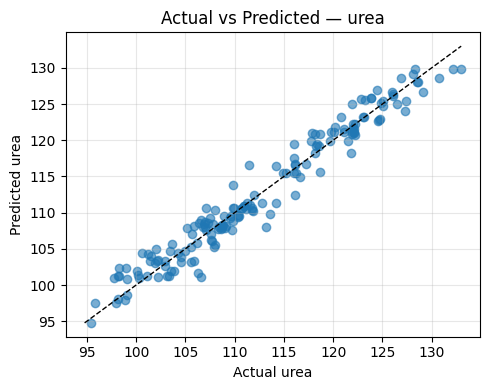

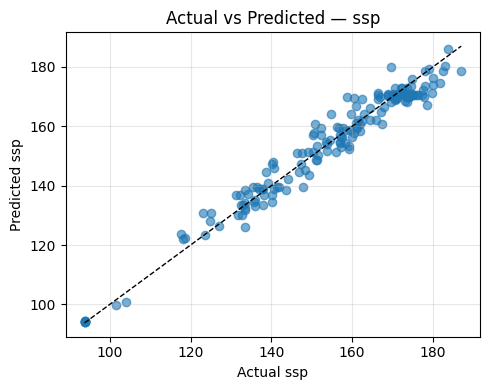

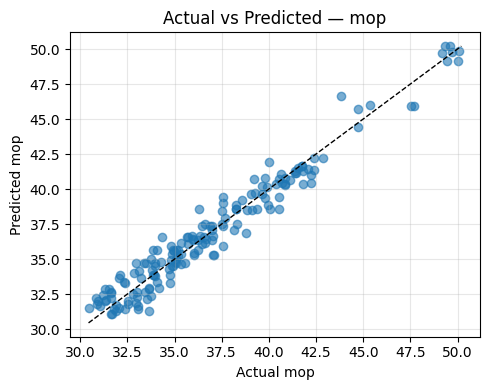

In [50]:
import matplotlib.pyplot as plt

outputs = y.columns.tolist()
preds = final_model.predict(X_test)

for i, col in enumerate(outputs):
    plt.figure(figsize=(5,4))
    plt.scatter(y_test[col], preds[:, i], alpha=0.6)
    lims = (min(y_test[col].min(), preds[:,i].min()), max(y_test[col].max(), preds[:,i].max()))
    plt.plot(lims, lims, 'k--', linewidth=1)  # 45-degree line
    plt.xlabel('Actual ' + col)
    plt.ylabel('Predicted ' + col)
    plt.title(f'Actual vs Predicted — {col}')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [51]:
import joblib

# Save the final tuned Random Forest model
joblib.dump(final_model, "best_fertilizer_model.pkl")

print("✅ Model saved successfully as best_fertilizer_model.pkl")


✅ Model saved successfully as best_fertilizer_model.pkl


In [52]:
sample = X_test.iloc[[0]]
print("Sample input:", sample)

pred = final_model.predict(sample)[0]   # <--- updated
print("\nPredicted fertilizer doses (kg/acre):")
print(f"Urea: {pred[0]:.2f}")
print(f"SSP : {pred[1]:.2f}")
print(f"MOP : {pred[2]:.2f}")


Sample input:          N     P      K    pH
736  104.0  21.0  175.0  6.92

Predicted fertilizer doses (kg/acre):
Urea: 107.80
SSP : 137.22
MOP : 34.72


In [54]:
import shap

d:\project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [55]:
shap.initjs()


In [56]:
# Use a subset of the test set for SHAP (faster & enough for explanation)
X_sample = X_test.sample(100, random_state=42)

feature_names = X_sample.columns.tolist()
feature_names


['N', 'P', 'K', 'pH']

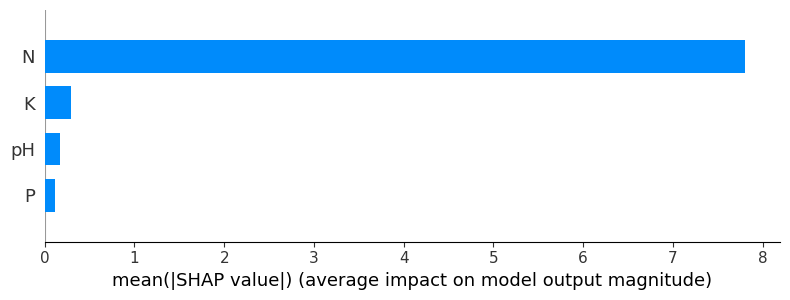

In [57]:
# Urea model = first estimator inside MultiOutputRegressor
rf_urea = final_model.estimators_[0]

explainer_urea = shap.TreeExplainer(rf_urea)
shap_values_urea = explainer_urea.shap_values(X_sample)

# 1) Bar plot – global feature importance for Urea
shap.summary_plot(
    shap_values_urea,
    X_sample,
    plot_type="bar",
    feature_names=feature_names
)


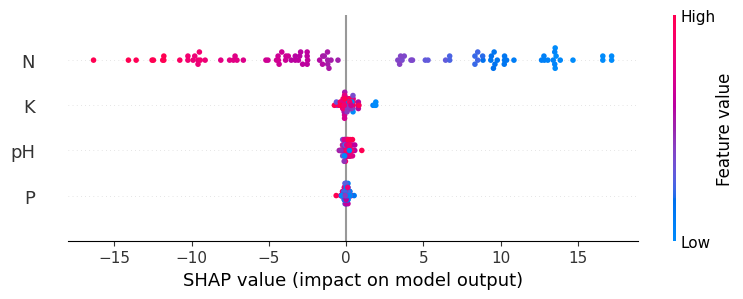

In [58]:
# 2) Beeswarm plot – how each feature value affects Urea
shap.summary_plot(
    shap_values_urea,
    X_sample,
    feature_names=feature_names
)


Low N (blue dots) → SHAP is positive → increases predicted Urea

High N (red dots) → SHAP is negative → decreases predicted Urea

This is EXACTLY how urea recommendation should behave.

✔ Soil low in nitrogen → more urea needed
✔ Soil high in nitrogen → less urea needed

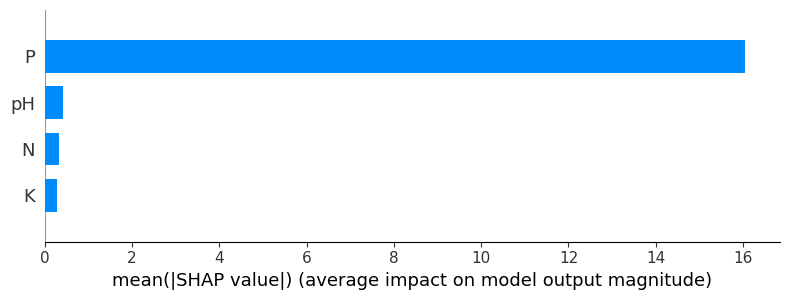

In [59]:
# SSP model = second estimator
rf_ssp = final_model.estimators_[1]

explainer_ssp = shap.TreeExplainer(rf_ssp)
shap_values_ssp = explainer_ssp.shap_values(X_sample)

# Global importance for SSP
shap.summary_plot(
    shap_values_ssp,
    X_sample,
    plot_type="bar",
    feature_names=feature_names
)


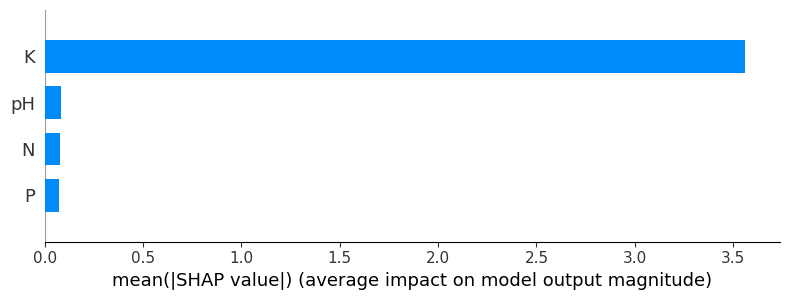

In [60]:
# MOP model = third estimator
rf_mop = final_model.estimators_[2]

explainer_mop = shap.TreeExplainer(rf_mop)
shap_values_mop = explainer_mop.shap_values(X_sample)

# Global importance for MOP
shap.summary_plot(
    shap_values_mop,
    X_sample,
    plot_type="bar",
    feature_names=feature_names
)


Soil sample:


,N,P,K,pH
736,104.0,21.0,175.0,6.92


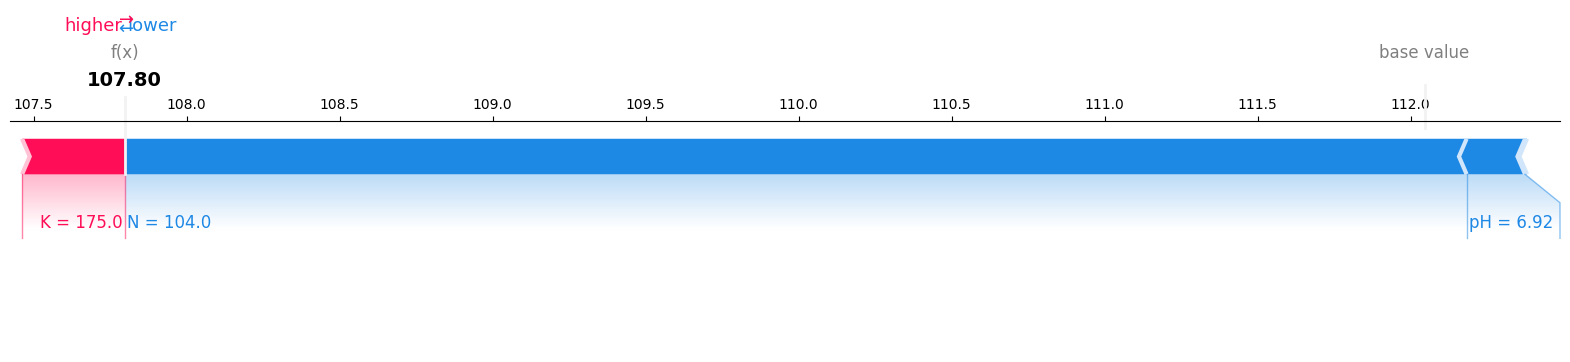

In [61]:
# Pick a single example from test set
x_one = X_test.iloc[[0]]

print("Soil sample:")
display(x_one)

# SHAP for that one sample (Urea)
shap_values_one_urea = explainer_urea.shap_values(x_one)

shap.force_plot(
    explainer_urea.expected_value,
    shap_values_one_urea,
    x_one,
    matplotlib=True
)


In [62]:
# Are required variables present?
print('best_params' in globals(), 'rf_tuned' in globals(), 'final_model' in globals())

# Sizes
print("X shape:", X.shape, "y shape:", y.shape, "X_test shape:", X_test.shape)


True True True
X shape: (832, 4) y shape: (832, 3) X_test shape: (167, 4)
